# Conway's Game of Life - Cython Implementations

This notebook explores the performance improvements of translating a pure Python implementation into Cython, step-by-step, ending with a Cythonized Numpy implementation.

## Implementation Differences
- **Python**: The baseline pure python implementation utilizing standard dynamic typing and nested loops.
- **Cython 1**: The exact same python code compiled with the Cython compiler. By merely running the code through the compiler, there's a slight speedup due to C variable overhead reduction.
- **Cython 2**: Introduced static C typing for the loop iterators (`i, j`) and scalar variables (`box_length, n_neigh`) via the `cdef int` declaration. This provides a significant speedup by removing python object type-checking and reference counting during the tight inner loops.
- **Cython 3**: Changing `update_rule` from a python `def` to a C-level function `cdef int`. By removing the Python function call overhead and operating purely at the C-level for every cell update, the execution time improves massively.
- **Cython 4**: Added compiler directives `# cython: boundscheck=False` and `# cython: wraparound=False`. This tells Cython to skip checking if array indices are out of bounds and stops supporting negative indexing (like `[-1]`), stripping away the final layers of built-in safety nets inside the loops for maximum C-level array access speed.

In [1]:
import time
import copy
import numpy as np
import matplotlib.pyplot as plt

%load_ext Cython
%matplotlib inline

## Initialization (Cross, Box Size 300)
We build a 300x300 lattice, padded to 302x302 to handle boundary neighbors.

In [2]:
N = 300
lattice = [[0 for _ in range(N + 2)] for _ in range(N + 2)]

# Draw a cross in the center
mid = N // 2 + 1
for i in range(1, N + 1):
    lattice[mid][i] = 1
    lattice[i][mid] = 1

initial_lattice_py = copy.deepcopy(lattice)
initial_lattice_np = np.array(lattice, dtype=np.int32)

## 1. Pure Python

In [3]:
def update_py(lattice):
    box_length = len(lattice) - 2
    lattice_new = [[0 for _ in range(box_length + 2)] for _ in range(box_length + 2)]
    for i in range(1, box_length + 1):
        for j in range(1, box_length + 1):
            lattice_new[i][j] = update_rule_py(lattice, i, j)
    return lattice_new

def update_rule_py(lattice, i, j):
    n_neigh = lattice[i + 1][j] + lattice[i][j + 1] + lattice[i + 1][j + 1] + \
              lattice[i + 1][j - 1] + lattice[i - 1][j] + lattice[i][j - 1] + \
              lattice[i - 1][j + 1] + lattice[i - 1][j - 1]
    if (lattice[i][j] == 1) and (n_neigh in [2, 3]):
        return 1
    elif lattice[i][j] == 1:
        return 0
    elif (lattice[i][j] == 0) and (n_neigh == 3):
        return 1
    else:
        return 0

## 2. Cython 1 (Compiled Python)

In [4]:
%%cython

def update_cy1(lattice):
    box_length = len(lattice) - 2
    lattice_new = [[0 for _ in range(box_length + 2)] for _ in range(box_length + 2)]
    for i in range(1, box_length + 1):
        for j in range(1, box_length + 1):
            lattice_new[i][j] = update_rule_cy1(lattice, i, j)
    return lattice_new

def update_rule_cy1(lattice, i, j):
    n_neigh = lattice[i + 1][j] + lattice[i][j + 1] + lattice[i + 1][j + 1] + \
              lattice[i + 1][j - 1] + lattice[i - 1][j] + lattice[i][j - 1] + \
              lattice[i - 1][j + 1] + lattice[i - 1][j - 1]
    if (lattice[i][j] == 1) and (n_neigh in [2, 3]):
        return 1
    elif lattice[i][j] == 1:
        return 0
    elif (lattice[i][j] == 0) and (n_neigh == 3):
        return 1
    else:
        return 0

Content of stdout:
_cython_magic_bd81bd806f97a4648ded849f9bf8feaf8ada356d947d2fd7cda68589b0cf0acc.c
   Creando biblioteca C:\Users\josea\.ipython\cython\Users\josea\.ipython\cython\_cython_magic_bd81bd806f97a4648ded849f9bf8feaf8ada356d947d2fd7cda68589b0cf0acc.cp312-win_amd64.lib y objeto C:\Users\josea\.ipython\cython\Users\josea\.ipython\cython\_cython_magic_bd81bd806f97a4648ded849f9bf8feaf8ada356d947d2fd7cda68589b0cf0acc.cp312-win_amd64.exp
Generando c¢digo
Generaci¢n de c¢digo finalizada

## 3. Cython 2 (Static Typing)

In [5]:
%%cython

def update_cy2(lattice):
    cdef int box_length = len(lattice) - 2
    cdef int i, j
    lattice_new = [[0 for _ in range(box_length + 2)] for _ in range(box_length + 2)]
    for i in range(1, box_length + 1):
        for j in range(1, box_length + 1):
            lattice_new[i][j] = update_rule_cy2(lattice, i, j)
    return lattice_new

def update_rule_cy2(lattice, int i, int j):
    cdef int n_neigh
    n_neigh = lattice[i + 1][j] + lattice[i][j + 1] + lattice[i + 1][j + 1] + \
              lattice[i + 1][j - 1] + lattice[i - 1][j] + lattice[i][j - 1] + \
              lattice[i - 1][j + 1] + lattice[i - 1][j - 1]
    if (lattice[i][j] == 1) and (n_neigh in [2, 3]):
        return 1
    elif lattice[i][j] == 1:
        return 0
    elif (lattice[i][j] == 0) and (n_neigh == 3):
        return 1
    else:
        return 0

Content of stdout:
_cython_magic_fc0c737f050b1d18a097b2e2569f4438a129af75610975e73543627b999b1d7e.c
C:\Users\josea\.ipython\cython\_cython_magic_fc0c737f050b1d18a097b2e2569f4438a129af75610975e73543627b999b1d7e.c(2573): warning C4244: '=': conversi¢n de 'Py_ssize_t' a 'int'; posible prdida de datos
   Creando biblioteca C:\Users\josea\.ipython\cython\Users\josea\.ipython\cython\_cython_magic_fc0c737f050b1d18a097b2e2569f4438a129af75610975e73543627b999b1d7e.cp312-win_amd64.lib y objeto C:\Users\josea\.ipython\cython\Users\josea\.ipython\cython\_cython_magic_fc0c737f050b1d18a097b2e2569f4438a129af75610975e73543627b999b1d7e.cp312-win_amd64.exp
Generando c¢digo
Generaci¢n de c¢digo finalizada

## 4. Cython 3 (C Function)

In [6]:
%%cython

def update_cy3(lattice):
    cdef int box_length = len(lattice) - 2
    cdef int i, j
    lattice_new = [[0 for _ in range(box_length + 2)] for _ in range(box_length + 2)]
    for i in range(1, box_length + 1):
        for j in range(1, box_length + 1):
            lattice_new[i][j] = update_rule_cy3(lattice, i, j)
    return lattice_new

cdef int update_rule_cy3(list lattice, int i, int j):
    cdef int n_neigh
    n_neigh = lattice[i + 1][j] + lattice[i][j + 1] + lattice[i + 1][j + 1] + \
              lattice[i + 1][j - 1] + lattice[i - 1][j] + lattice[i][j - 1] + \
              lattice[i - 1][j + 1] + lattice[i - 1][j - 1]
    if (lattice[i][j] == 1) and (n_neigh in [2, 3]):
        return 1
    elif lattice[i][j] == 1:
        return 0
    elif (lattice[i][j] == 0) and (n_neigh == 3):
        return 1
    else:
        return 0

Content of stdout:
_cython_magic_a0cc93b8e2c29e9f561a373f76aaa612f5df56c95a9106091f3c1c977723bc6c.c
C:\Users\josea\.ipython\cython\_cython_magic_a0cc93b8e2c29e9f561a373f76aaa612f5df56c95a9106091f3c1c977723bc6c.c(2546): warning C4244: '=': conversi¢n de 'Py_ssize_t' a 'int'; posible prdida de datos
   Creando biblioteca C:\Users\josea\.ipython\cython\Users\josea\.ipython\cython\_cython_magic_a0cc93b8e2c29e9f561a373f76aaa612f5df56c95a9106091f3c1c977723bc6c.cp312-win_amd64.lib y objeto C:\Users\josea\.ipython\cython\Users\josea\.ipython\cython\_cython_magic_a0cc93b8e2c29e9f561a373f76aaa612f5df56c95a9106091f3c1c977723bc6c.cp312-win_amd64.exp
Generando c¢digo
Generaci¢n de c¢digo finalizada

## 5. Cython 4 (Compiler Directives)

In [7]:
%%cython
# cython: boundscheck=False
# cython: wraparound=False

def update_cy4(lattice):
    cdef int box_length = len(lattice) - 2
    cdef int i, j
    lattice_new = [[0 for _ in range(box_length + 2)] for _ in range(box_length + 2)]
    for i in range(1, box_length + 1):
        for j in range(1, box_length + 1):
            lattice_new[i][j] = update_rule_cy4(lattice, i, j)
    return lattice_new

cdef int update_rule_cy4(list lattice, int i, int j):
    cdef int n_neigh
    n_neigh = lattice[i + 1][j] + lattice[i][j + 1] + lattice[i + 1][j + 1] + \
              lattice[i + 1][j - 1] + lattice[i - 1][j] + lattice[i][j - 1] + \
              lattice[i - 1][j + 1] + lattice[i - 1][j - 1]
    if (lattice[i][j] == 1) and (n_neigh in [2, 3]):
        return 1
    elif lattice[i][j] == 1:
        return 0
    elif (lattice[i][j] == 0) and (n_neigh == 3):
        return 1
    else:
        return 0

Content of stdout:
_cython_magic_b1dfb728da4482f37db5c60f4bee315e1900583f7d1beef40f8c0cde3fdb4da1.c
C:\Users\josea\.ipython\cython\_cython_magic_b1dfb728da4482f37db5c60f4bee315e1900583f7d1beef40f8c0cde3fdb4da1.c(2547): warning C4244: '=': conversi¢n de 'Py_ssize_t' a 'int'; posible prdida de datos
   Creando biblioteca C:\Users\josea\.ipython\cython\Users\josea\.ipython\cython\_cython_magic_b1dfb728da4482f37db5c60f4bee315e1900583f7d1beef40f8c0cde3fdb4da1.cp312-win_amd64.lib y objeto C:\Users\josea\.ipython\cython\Users\josea\.ipython\cython\_cython_magic_b1dfb728da4482f37db5c60f4bee315e1900583f7d1beef40f8c0cde3fdb4da1.cp312-win_amd64.exp
Generando c¢digo
Generaci¢n de c¢digo finalizada

## 6. Cythonized NumPy Implementation
Applying Cython memoryviews (`int[:, :]`) directly to the NumPy array to achieve maximum raw execution speed natively.

In [8]:
%%cython
# cython: boundscheck=False
# cython: wraparound=False
import numpy as np

def update_numpy_cython(int[:, :] lattice):
    cdef int box_length = lattice.shape[0] - 2
    cdef int[:, :] lattice_new = np.zeros((box_length + 2, box_length + 2), dtype=np.int32)
    cdef int i, j, n_neigh, current

    for i in range(1, box_length + 1):
        for j in range(1, box_length + 1):
            n_neigh = lattice[i + 1, j] + lattice[i, j + 1] + lattice[i + 1, j + 1] + \
                      lattice[i + 1, j - 1] + lattice[i - 1, j] + lattice[i, j - 1] + \
                      lattice[i - 1, j + 1] + lattice[i - 1, j - 1]
            current = lattice[i, j]
            if current == 1 and (n_neigh == 2 or n_neigh == 3):
                lattice_new[i, j] = 1
            elif current == 0 and n_neigh == 3:
                lattice_new[i, j] = 1
    
    return np.asarray(lattice_new)

Content of stdout:
_cython_magic_b611a41e2ac1e334dac90658825763c09576f2548b0d5ca4fe4b6a09e57aaed6.c
C:\Users\josea\.ipython\cython\_cython_magic_b611a41e2ac1e334dac90658825763c09576f2548b0d5ca4fe4b6a09e57aaed6.c(16662): warning C4244: '=': conversi¢n de 'Py_ssize_t' a 'int'; posible prdida de datos
   Creando biblioteca C:\Users\josea\.ipython\cython\Users\josea\.ipython\cython\_cython_magic_b611a41e2ac1e334dac90658825763c09576f2548b0d5ca4fe4b6a09e57aaed6.cp312-win_amd64.lib y objeto C:\Users\josea\.ipython\cython\Users\josea\.ipython\cython\_cython_magic_b611a41e2ac1e334dac90658825763c09576f2548b0d5ca4fe4b6a09e57aaed6.cp312-win_amd64.exp
Generando c¢digo
Generaci¢n de c¢digo finalizada

## Benchmarking All Versions (300 Updates)

In [9]:
updates = 300
times = {}

# Functions dict mapping to (initial_lattice, function_to_call)
versions = {
    'Python': (initial_lattice_py, update_py),
    'Cython 1': (initial_lattice_py, update_cy1),
    'Cython 2': (initial_lattice_py, update_cy2),
    'Cython 3': (initial_lattice_py, update_cy3),
    'Cython 4': (initial_lattice_py, update_cy4),
    'NumPy + Cython': (initial_lattice_np, update_numpy_cython)
}

for version_name, (init_lattice, update_func) in versions.items():
    # Deepcopy to prevent mutating initial state for lists, .copy for arrays
    if isinstance(init_lattice, list):
        current_lattice = copy.deepcopy(init_lattice)
    else:
        current_lattice = init_lattice.copy()
        
    print(f"Benchmarking {version_name}...")
    start_time = time.time()
    for _ in range(updates):
        current_lattice = update_func(current_lattice)
    duration = time.time() - start_time
    times[version_name] = duration
    print(f"{version_name} finished in {duration:.4f} seconds.\n")

Benchmarking Python...
Python finished in 35.9492 seconds.

Benchmarking Cython 1...
Cython 1 finished in 25.9168 seconds.

Benchmarking Cython 2...
Cython 2 finished in 13.3610 seconds.

Benchmarking Cython 3...
Cython 3 finished in 10.7014 seconds.

Benchmarking Cython 4...
Cython 4 finished in 7.9677 seconds.

Benchmarking NumPy + Cython...
NumPy + Cython finished in 0.2533 seconds.



## Performance Comparison Chart

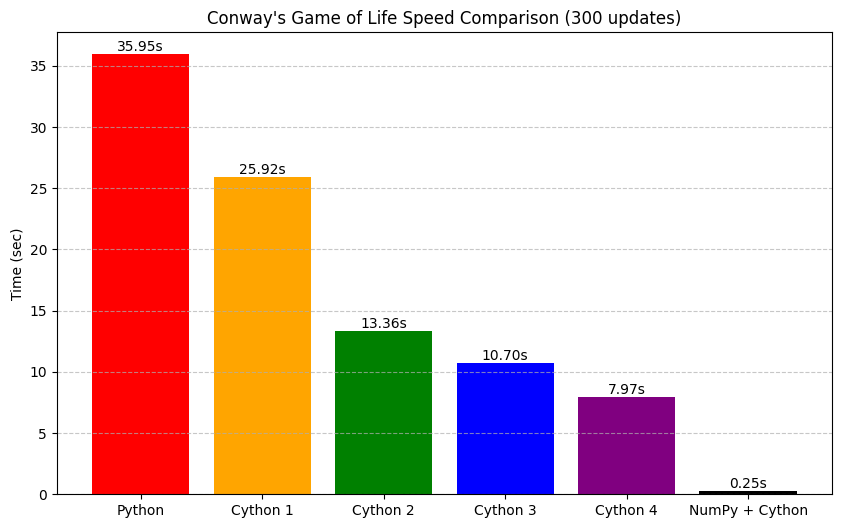

In [10]:
labels = list(times.keys())
durations = list(times.values())

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, durations, color=['red', 'orange', 'green', 'blue', 'purple', 'black'])
plt.ylabel('Time (sec)')
plt.title(f'Conway\'s Game of Life Speed Comparison ({updates} updates)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add text annotations on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}s', va='bottom', ha='center')

plt.show()